# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [10]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [11]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w724_s10"
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / "reconstruction_analysis"

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (27): ['AE_12dim_0005', 'AE_15dim_0003', 'AE_20dim_0004', 'AE_3dim_0003', 'AE_70dim_0005', 'linearAE_12dim_0001_biasFalse', 'linearAE_12dim_0003', 'linearAE_12dim_0005', 'linearAE_15dim_0001_biasFalse', 'linearAE_15dim_0002', 'linearAE_20dim_0001', 'linearAE_20dim_0001_biasFalse', 'linearAE_3dim_0001', 'linearAE_3dim_0001_biasFalse', 'linearAE_70dim_0001', 'linearAE_70dim_0001_biasFalse', 'PCA_100dim', 'PCA_12dim', 'PCA_150dim', 'PCA_15dim', 'PCA_1dim', 'PCA_200dim', 'PCA_20dim', 'PCA_289dim', 'PCA_3dim', 'PCA_50dim', 'PCA_70dim']


In [12]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / "reconstruction_errors.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_12dim_0005'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_15dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_20dim_0004'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_3dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_70dim_0005'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/linearAE_12dim_0001_biasFalse'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelatio

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_max,mst_avg_path_len_unweighted_recon_count,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_1dim,0.004756,0.001796,0.002039,0.004793,0.010289,0.053000,0.010214,0.035379,0.053617,0.081013,24.553280,4.574602,16.345898,25.062355,36.720142,41.0,44.233498,5.794852,31.301939,40.166205,45.152355,47.922438,55.678670,41.0,28.569126,...,14.683491,41.0,9.741744,0.725577,7.987435,9.279227,9.848548,10.134908,11.020646,41.0,1.552112,1.407815,0.028864,0.513766,0.931605,2.137203,5.338914,41.0,28.780488,12.082037,10.0,20.0,30.0,40.0,70.0
PCA_3dim,0.001921,0.001637,0.000458,0.001462,0.008272,0.031826,0.011986,0.014902,0.029399,0.071902,14.982809,5.288825,7.748679,13.841881,32.923794,41.0,57.631241,8.851695,33.518006,52.631579,59.279778,63.711911,70.360111,41.0,40.986927,...,14.683491,41.0,9.978015,1.835963,6.674385,8.843896,9.644220,10.842947,14.726956,41.0,1.646216,1.124040,0.206608,0.777200,1.489784,2.294318,4.408763,41.0,40.487805,15.321752,10.0,30.0,40.0,50.0,80.0
PCA_12dim,0.000305,0.000126,0.000121,0.000263,0.000560,0.012790,0.002936,0.007838,0.012512,0.018273,6.194665,1.296237,3.981848,5.867055,8.569008,41.0,78.859537,5.216089,68.144044,75.900277,78.947368,82.548476,90.858726,41.0,65.395865,...,14.683491,41.0,10.658401,1.646324,7.265071,9.468404,10.304235,11.794708,14.130087,41.0,0.921816,0.718735,0.046035,0.261995,0.738556,1.505869,2.425169,41.0,59.268293,19.797758,10.0,50.0,60.0,70.0,100.0
PCA_15dim,0.000231,0.000099,0.000120,0.000193,0.000554,0.011172,0.002485,0.007498,0.010169,0.018188,5.389203,1.119492,3.963244,5.028235,8.523526,41.0,80.420242,4.447445,70.083102,78.116343,79.778393,84.487535,90.858726,41.0,67.479168,...,14.683491,41.0,10.421157,1.523835,7.723191,9.416109,9.860853,11.467960,13.696699,41.0,0.917631,0.764744,0.004255,0.361412,0.713641,1.286420,2.829785,41.0,60.487805,19.229043,10.0,50.0,60.0,70.0,100.0
PCA_20dim,0.000167,0.000072,0.000072,0.000144,0.000305,0.009447,0.002199,0.005918,0.009123,0.013147,4.566986,0.997865,3.071701,4.341506,6.321898,41.0,82.974123,4.139443,74.238227,79.778393,82.825485,86.703601,91.135734,41.0,71.110876,...,14.683491,41.0,10.496001,1.509354,7.830290,9.337675,10.530326,11.399565,13.856400,41.0,0.723143,0.678465,0.029966,0.214169,0.537534,1.028420,3.360187,41.0,70.487805,15.803674,40.0,60.0,70.0,80.0,100.0
PCA_50dim,0.000063,0.000037,0.000013,0.000055,0.000175,0.005741,0.001667,0.002741,0.005497,0.009552,2.762727,0.783251,1.292809,2.673885,4.794024,41.0,88.521046,3.305609,81.440443,85.872576,88.365651,91.135734,94.182825,41.0,79.559246,...,14.683491,41.0,10.526408,1.662541,7.610979,9.354448,10.220061,11.453789,14.225632,41.0,0.584

In [13]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

print("Reconstruction error means (lower is better):")
display(sort_by_method_k(err_means))

print("Reconstruction error std:")
display(sort_by_method_k(err_stds))

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)
err_ranks = err_ranks.sort_values("avg_rank")

print("Reconstruction error rank (lower is better):")
display(sort_by_method_k(err_ranks))

Reconstruction error means (lower is better):


,MSE,MAE,Frobenius
model,,,
PCA_1dim,0.004756,0.053000,24.553280
PCA_3dim,0.001921,0.031826,14.982809
PCA_12dim,0.000305,0.012790,6.194665
PCA_15dim,0.000231,0.011172,5.389203
PCA_20dim,0.000167,0.009447,4.566986
PCA_50dim,0.000063,0.005741,2.762727
PCA_70dim,0.000048,0.004938,2.380316
PCA_100dim,0.000037,0.004265,2.061727
PCA_150dim,0.000029,0.003744,1.821231


Reconstruction error std:


,MSE,MAE,Frobenius
model,,,
PCA_1dim,0.001796,0.010214,4.574602
PCA_3dim,0.001637,0.011986,5.288825
PCA_12dim,0.000126,0.002936,1.296237
PCA_15dim,0.000099,0.002485,1.119492
PCA_20dim,0.000072,0.002199,0.997865
PCA_50dim,0.000037,0.001667,0.783251
PCA_70dim,0.000031,0.001596,0.763220
PCA_100dim,0.000027,0.001530,0.738857
PCA_150dim,0.000025,0.001518,0.736154


Reconstruction error rank (lower is better):


,MSE,MAE,Frobenius,avg_rank
model,,,,
PCA_1dim,24.0,24.0,24.0,24.000000
PCA_3dim,21.0,21.0,21.0,21.000000
PCA_12dim,12.0,12.0,12.0,12.000000
PCA_15dim,10.0,10.0,10.0,10.000000
PCA_20dim,7.0,7.0,7.0,7.000000
PCA_50dim,6.0,6.0,6.0,6.000000
PCA_70dim,5.0,5.0,5.0,5.000000
PCA_100dim,4.0,4.0,4.0,4.000000
PCA_150dim,3.0,3.0,3.0,3.000000


In [14]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)

print("MST comparison means:")
display(sort_by_method_k(mst_means))

higher_better = {"edge_overlap_pct", "edge_jaccard_pct", "betweenness_topk_overlap_pct"}
lower_better = {"degree_l1", "avg_path_len_diff", "avg_path_len_unweighted_diff"}


def rank_mst(df: pd.DataFrame):
    ranks = pd.DataFrame(index=df.index)
    for metric in df.columns:
        if metric in higher_better:
            ranks[metric] = df[metric].rank(ascending=False)
        else:
            ranks[metric] = df[metric].rank(ascending=True)
    ranks["avg_rank"] = ranks.mean(axis=1)
    return ranks.sort_values("avg_rank")


mst_ranks = rank_mst(mst_means)
print("MST rank (higher overlap is better, lower diffs are better):")
display(sort_by_method_k(mst_ranks))

MST comparison means:


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct
model,,,,,,
PCA_1dim,44.233498,28.569126,0.126802,1.065597,1.552112,28.780488
PCA_3dim,57.631241,40.986927,0.107398,1.046714,1.646216,40.487805
PCA_12dim,78.859537,65.395865,0.087994,0.617721,0.921816,59.268293
PCA_15dim,80.420242,67.479168,0.085164,0.573974,0.917631,60.487805
PCA_20dim,82.974123,71.110876,0.083951,0.463607,0.723143,70.487805
PCA_50dim,88.521046,79.559246,0.074114,0.378066,0.584005,78.292683
PCA_70dim,89.845281,81.712810,0.064951,0.334567,0.511555,78.536585
PCA_100dim,91.027633,83.671845,0.068185,0.292149,0.458752,80.487805
PCA_150dim,91.581650,84.650434,0.061043,0.274802,0.435291,84.878049


MST rank (higher overlap is better, lower diffs are better):


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct,avg_rank
model,,,,,,,
PCA_1dim,24.0,24.0,24.0,23.0,24.0,24.0,23.833333
PCA_3dim,21.0,21.0,21.0,22.0,25.0,21.0,21.833333
PCA_12dim,14.0,14.0,14.0,18.0,16.0,18.0,15.666667
PCA_15dim,11.0,11.0,10.0,12.0,14.0,16.0,12.333333
PCA_20dim,7.0,7.0,9.0,7.0,7.0,7.0,7.333333
PCA_50dim,6.0,6.0,6.0,6.0,6.0,6.0,6.000000
PCA_70dim,5.0,5.0,4.0,5.0,5.0,5.0,4.833333
PCA_100dim,4.0,4.0,5.0,4.0,4.0,4.0,4.166667
PCA_150dim,3.0,3.0,2.0,2.0,2.0,2.0,2.333333


In [15]:
summary = pd.DataFrame(index=stats_df.index)
summary["err_score"] = err_ranks["avg_rank"]
summary["mst_score"] = mst_ranks["avg_rank"]
summary["combined_score"] = summary.mean(axis=1)
summary = summary.sort_values("combined_score")

print("Combined score (lower is better):")
display(sort_by_method_k(summary))

Combined score (lower is better):


,err_score,mst_score,combined_score
model,,,
PCA_1dim,24.000000,23.833333,23.916667
PCA_3dim,21.000000,21.833333,21.416667
PCA_12dim,12.000000,15.666667,13.833333
PCA_15dim,10.000000,12.333333,11.166667
PCA_20dim,7.000000,7.333333,7.166667
PCA_50dim,6.000000,6.000000,6.000000
PCA_70dim,5.000000,4.833333,4.916667
PCA_100dim,4.000000,4.166667,4.083333
PCA_150dim,3.000000,2.333333,2.666667


# K-based comparison plots
Build plots for error metrics across K and methods.

In [16]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE_biasFalse": "LinearAE (biasFalse)",
    "linearAE": "LinearAE",
    "AE": "AE",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE_biasFalse": "tab:olive",
    "linearAE": "tab:green",
    "AE": "tab:red",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE_biasFalse', 'linearAE', 'AE']
K values: [np.int64(1), np.int64(3), np.int64(12), np.int64(15), np.int64(20), np.int64(50), np.int64(70), np.int64(100), np.int64(150), np.int64(200), np.int64(289)]


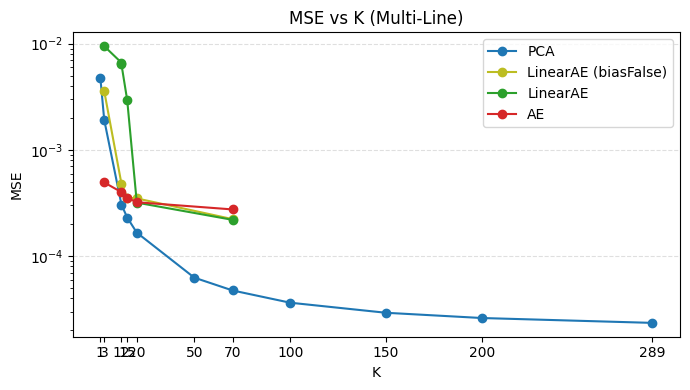

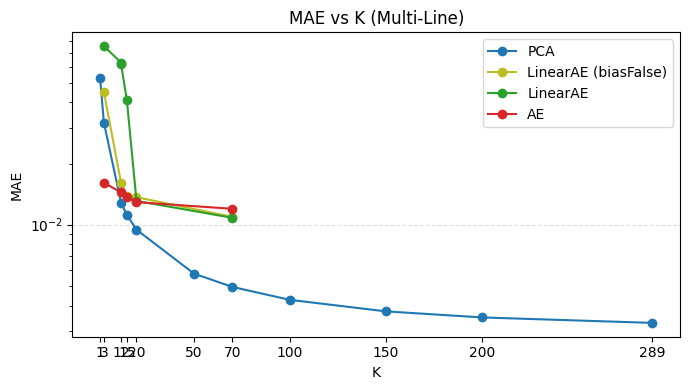

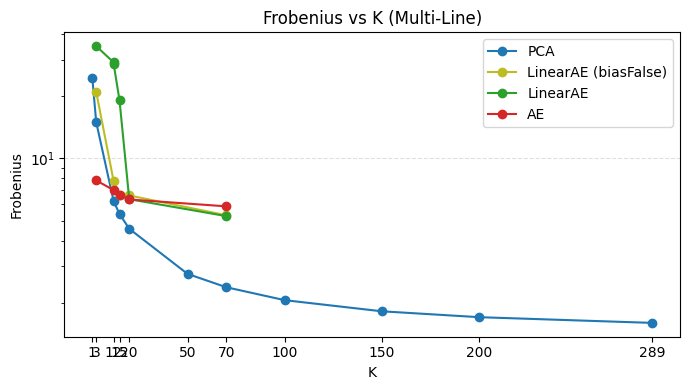

In [17]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        ax.set_xticks(sorted(set(all_x)))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

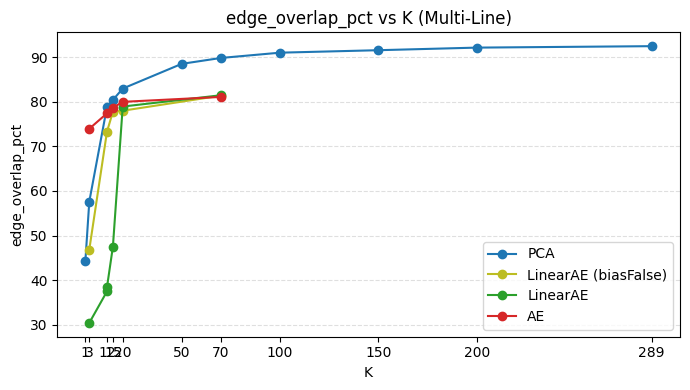

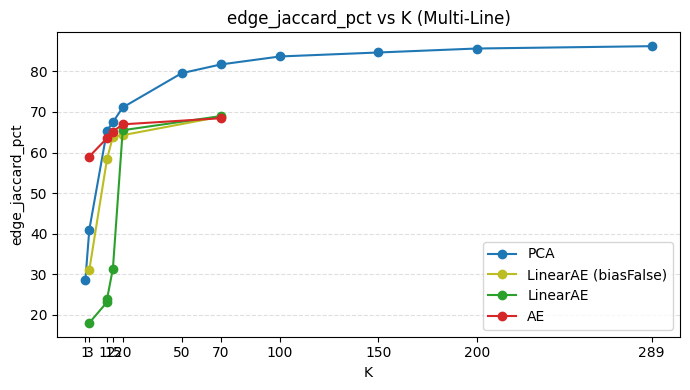

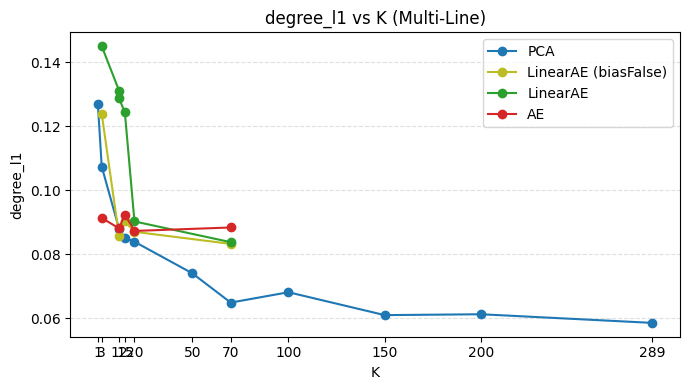

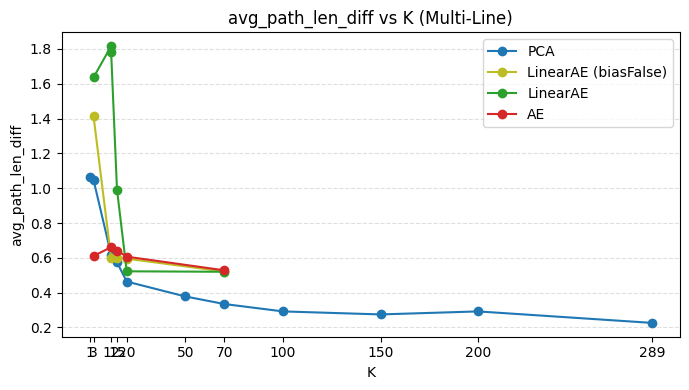

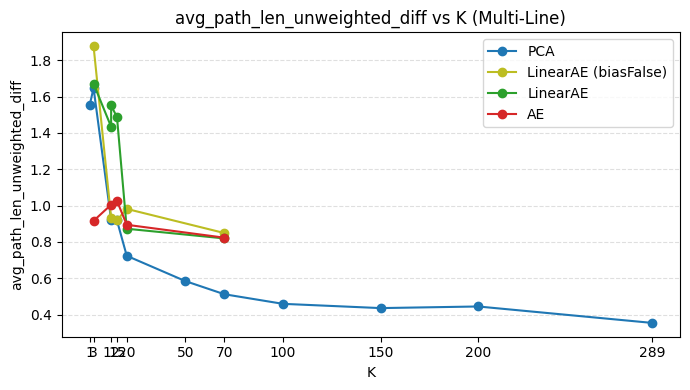

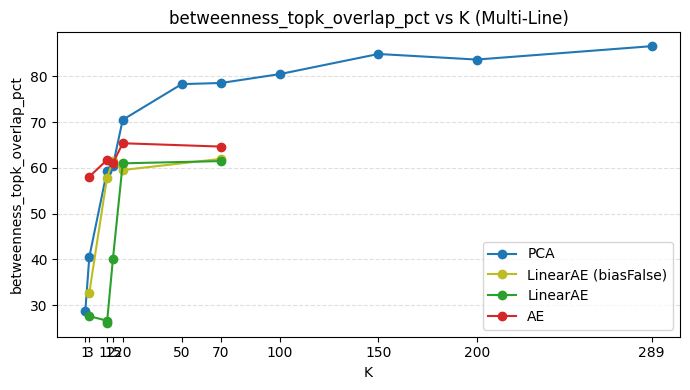

In [18]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        ax.set_xticks(sorted(set(all_x)))
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()